# Analyse spatio-temporelle du terrorisme mondial (GTD)

> ⚠️ **Cadre et éthique** — projet à visée **académique et analytique**. Il
> décrit des dynamiques historiques (1970-2017) à partir de données ouvertes ;
> il ne prétend **ni prédire des attaques**, ni cibler des populations, ni
> fonder des décisions opérationnelles. Les biais de reporting et les limites
> éthiques sont discutés en fin de notebook et dans le README.

**Angle décisionnel** — comprendre *où*, *quand* et *comment* le terrorisme se
manifeste, construire un **indice de pression** par pays et repérer des
**familles de pays** aux profils d'attaque similaires.

**Données** — Global Terrorism Database (START / University of Maryland),
**181 691 incidents**, 1970-2017. Chargée localement depuis le CSV officiel
Kaggle (non redistribuable).

**Plan** : nettoyage → EDA spatio-temporelle → indice de pression → clustering
→ modèles prédictifs → limites & éthique.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from preprocessing import load_clean

df = load_clean()
print(f"{len(df):,} incidents | {df.year.min()}-{df.year.max()}")
print(f"morts totales : {df.n_kill.sum():,.0f} | "
      f"incidents létaux : {df.lethal.mean()*100:.1f}%")
df[["year", "country", "region", "attack_type", "target_type",
    "n_kill", "n_wound"]].head()

181,691 incidents | 1970-2017
morts totales : 411,868 | incidents létaux : 45.8%


,year,country,region,attack_type,target_type,n_kill,n_wound
0,1970,Dominican Republic,Central America & Caribbean,Assassination,Private Citizens & Property,1.0,0.0
1,1970,Mexico,North America,Hostage Taking (Kidnapping),Government (Diplomatic),0.0,0.0
2,1970,Philippines,Southeast Asia,Assassination,Journalists & Media,1.0,0.0
3,1970,Greece,Western Europe,Bombing/Explosion,Government (Diplomatic),0.0,0.0
4,1970,Japan,East Asia,Facility/Infrastructure Attack,Government (Diplomatic),0.0,0.0


## 1. Qualité des données — l'incomplétude est un fait, pas un détail

La GTD est riche mais lacunaire par endroits : casualties parfois absentes,
groupe responsable inconnu une fois sur deux, et **l'année 1993 entièrement
perdue** par les archivistes de START. On quantifie ces trous avant toute
analyse.

In [2]:
quality = pd.Series({
    "casualties renseignées": df.casualties_known.mean(),
    "coordonnées valides": df.geo_known.mean(),
    "groupe identifié": df.group_known.mean(),
    "part année 1993 (perdue)": (df.year == 1993).mean(),
}).mul(100).round(1)
display(quality.to_frame("% des incidents"))

,% des incidents
casualties renseignées,90.7
coordonnées valides,97.5
groupe identifié,54.4
part année 1993 (perdue),0.0


## 2. EDA spatio-temporelle

Tendance globale (avec le trou de 1993), déplacement géographique par décennie,
et typologie des attaques et des cibles.

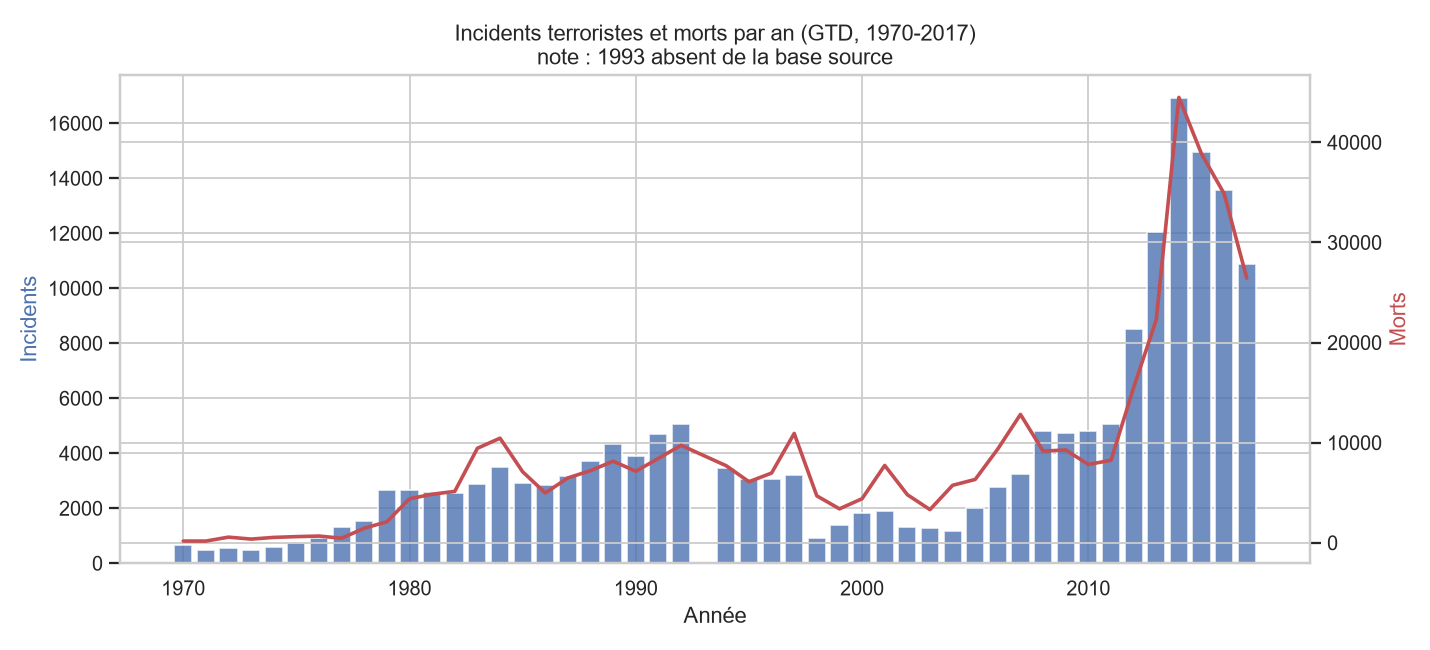

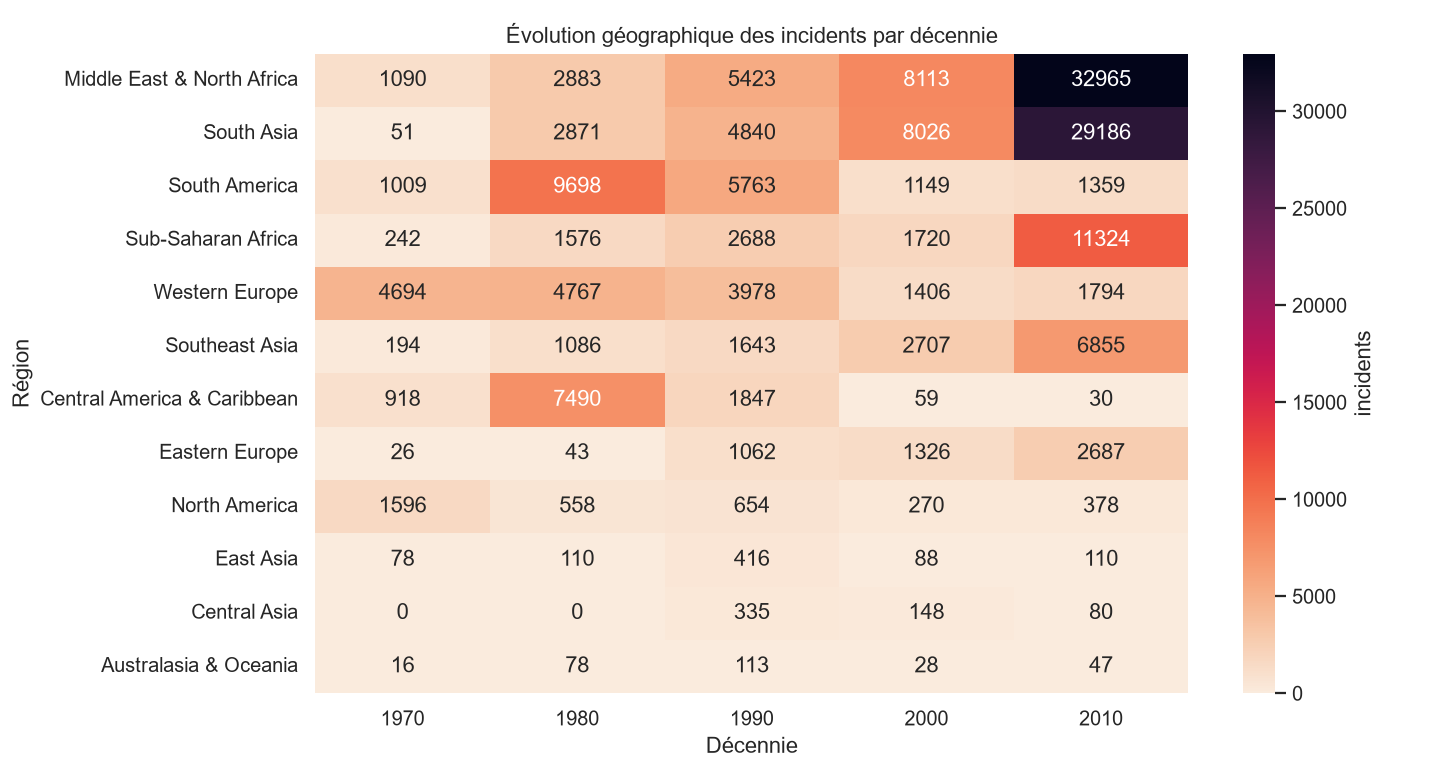

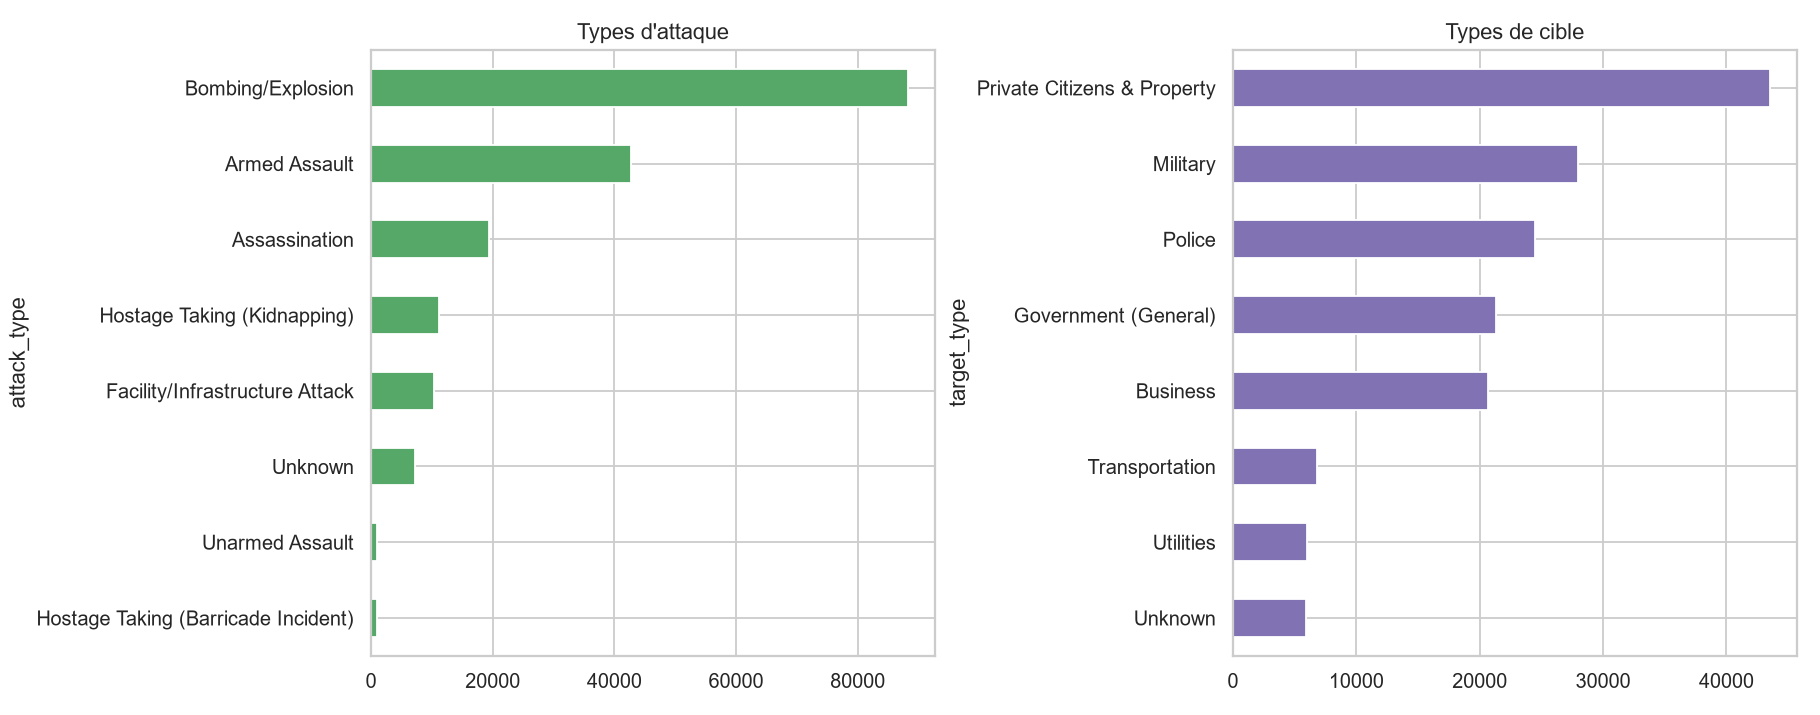

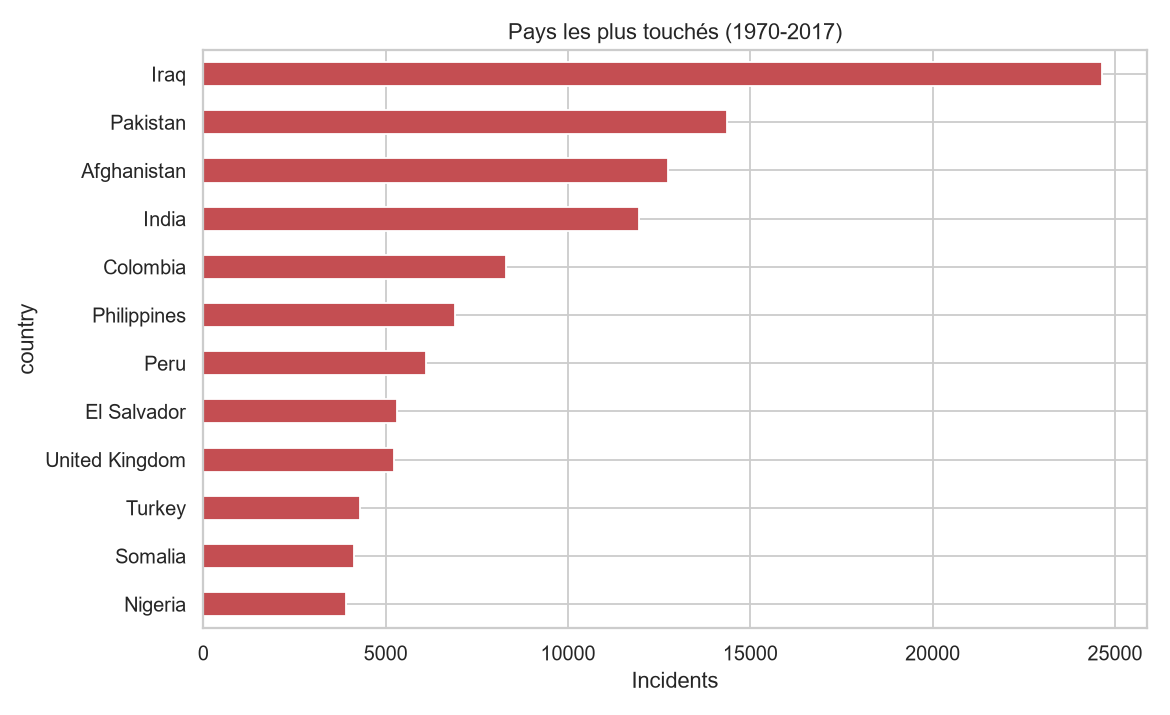

In [3]:
for fig in ["incidents_deaths_per_year.png", "region_decade_heatmap.png",
            "attack_target_typology.png", "top_countries.png"]:
    display(Image(ROOT / "reports" / "figures" / fig, width=820))

**Lecture** — après une activité modérée jusqu'aux années 2000, les incidents
explosent à partir de ~2004 pour culminer en **2014 (~16 900 incidents)**, tirés
par le Moyen-Orient/Afrique du Nord et l'Asie du Sud. Le **bombardement/explosif**
domine largement les modes opératoires, les **civils** sont la cible la plus
fréquente. Carte de densité interactive :
`reports/figures/incident_density_map.html`.

## 3. Indice de pression terroriste par pays

Composite normalisé : **fréquence** (0,4) + **létalité** (0,3) + **intensité**
moyenne par incident (0,15) + **récence** 2008-2017 (0,15). Descriptif et
relatif — pas une prévision.

,country,incidents,deaths,mean_severity,pressure_index
0,Iraq,24636,78589.0,5.924,0.842
1,Afghanistan,12731,39384.0,4.832,0.799
2,Pakistan,14368,23822.0,3.121,0.774
3,Nigeria,3907,22682.0,7.116,0.743
4,India,11960,19341.0,2.829,0.732
5,Somalia,4142,10273.0,3.552,0.714
6,Syria,2201,15229.0,10.124,0.712
7,Yemen,3347,8776.0,4.016,0.707
8,Philippines,6908,9559.0,2.351,0.690
9,Libya,2249,2598.0,1.891,0.660


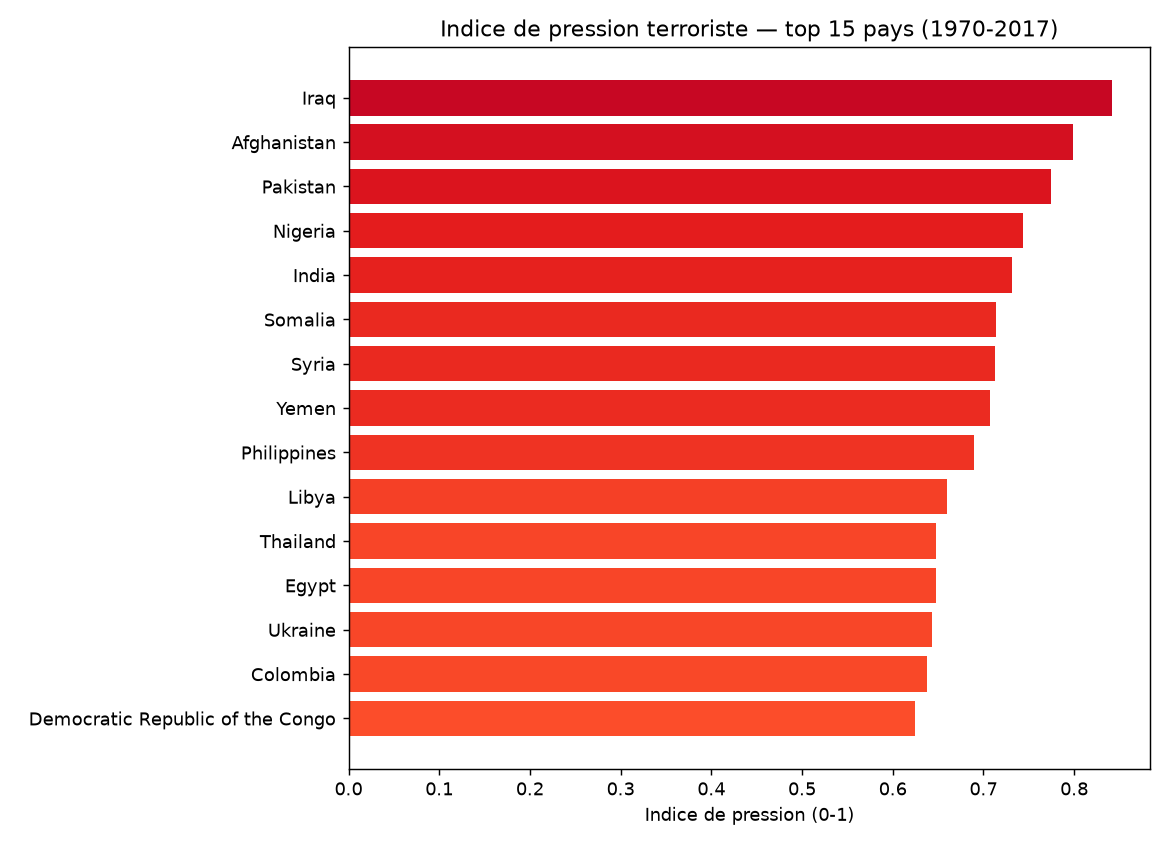

In [4]:
pressure = pd.read_csv(ROOT / "reports" / "pressure_index_country.csv")
display(pressure.head(12)[["country", "incidents", "deaths",
                           "mean_severity", "pressure_index"]].round(3))
display(Image(ROOT / "reports" / "figures" /
              "pressure_index_top_countries.png", width=720))

Irak, Afghanistan et Pakistan dominent l'indice, cohérent avec les faits connus.
La choroplèthe mondiale est dans `reports/figures/pressure_index_map.html`.

## 4. Familles de pays (clustering non supervisé)

K-Means sur le **profil comportemental** de chaque pays (mix de types
d'attaque/cible, taux de suicide et de létalité). K choisi par silhouette.

,cluster,n_countries,example_countries,distinctive_traits,lethality_rate,suicide_rate
0,0,13,"Sudan, Democratic Republic of the Congo, Mali,...",mean_severity(+7.16); lethality_rate(+0.26); t...,0.623950,0.044549
1,1,35,"Spain, United States, France, Chile",tgt_Business(+0.08); atk_Facility/Infrastructu...,0.154344,0.004848
2,2,63,"Iraq, Pakistan, Afghanistan, India",lethality_rate(+0.06); atk_Armed Assault(+0.03...,0.427071,0.019322


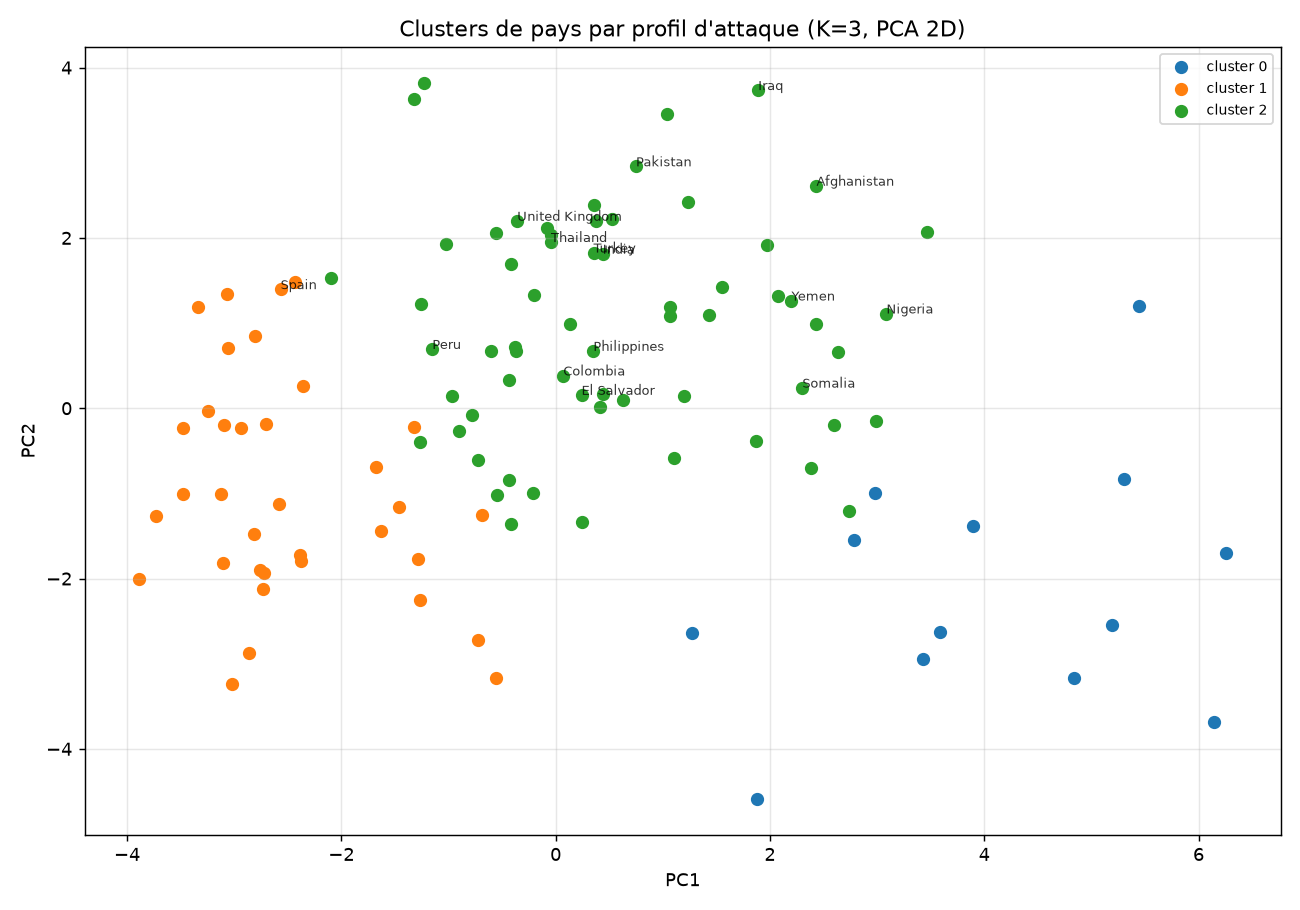

In [5]:
clusters = pd.read_csv(ROOT / "reports" / "cluster_summary.csv")
display(clusters)
display(Image(ROOT / "reports" / "figures" / "country_clusters.png", width=760))

**Lecture** — trois familles se dégagent : (0) pays à **forte létalité par
incident** (Sahel, RDC — assauts armés meurtriers) ; (1) profil **occidental**
à faible létalité, ciblant infrastructures et entreprises (Espagne, USA,
France) ; (2) pays à **fort volume et bombardements** (Irak, Pakistan,
Afghanistan). Le volume brut et le profil sont donc deux axes distincts.

## 5. Modèles prédictifs (split temporel honnête)

Entraînement sur ≤ 2013, test sur ≥ 2014 — prédire le futur à partir du passé.
Deux tâches à partir des seules caractéristiques de l'incident (région, type
d'attaque/cible/arme, suicide, année).

Classification — incident létal ?


,model,accuracy,roc_auc,f1
0,LogReg,0.678,0.761,0.660
1,GradientBoosting,0.711,0.776,0.718


Régression — sévérité (log1p)


,model,rmse_log,mae_casualties,r2_log
0,LinearRegression,0.866,3.547,0.193
1,GradientBoosting,0.839,3.424,0.242


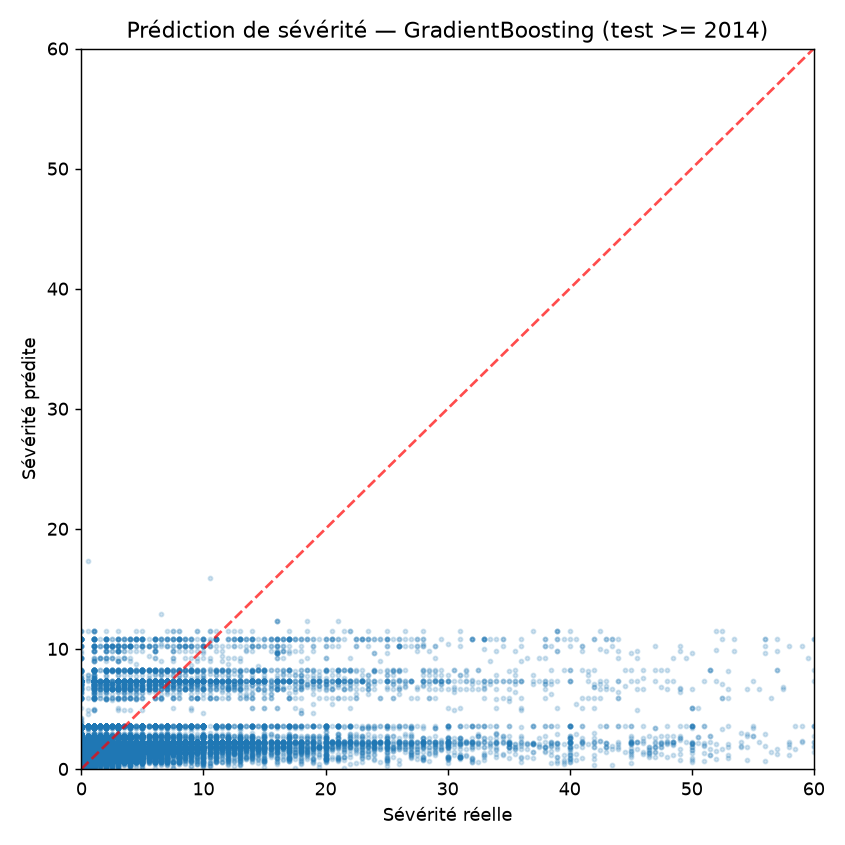

In [6]:
clf = pd.read_csv(ROOT / "reports" / "classification_metrics.csv")
reg = pd.read_csv(ROOT / "reports" / "regression_metrics.csv")
print("Classification — incident létal ?")
display(clf.round(3))
print("Régression — sévérité (log1p)")
display(reg.round(3))
display(Image(ROOT / "reports" / "figures" /
              "severity_pred_vs_actual.png", width=520))

**Lecture** — la léthalité est prédictible modérément (Gradient Boosting :
accuracy 0,71, ROC-AUC 0,78) : le *type d'attaque* et la *région* portent
l'essentiel du signal. La **sévérité exacte** reste difficile (R² ≈ 0,24) — sans
surprise : le nombre de victimes dépend de facteurs contingents (lieu précis,
foule, réponse) absents des features. C'est un résultat honnête, pas un échec :
il borne ce que ce type de données permet de dire.

## 6. Limites & éthique (section obligatoire)

**Biais de données**
- **Biais de reporting** : couverture médiatique et sources inégales selon les
  époques et les régions ; la hausse post-2004 mêle recrudescence réelle et
  meilleure documentation.
- **Incomplétude historique** : casualties manquantes (~9 %), groupe inconnu
  (~46 %), **année 1993 entièrement absente**.
- **Définition** : « terrorisme » repose sur les critères d'inclusion de START,
  qui comportent une part de jugement et évoluent dans le temps.

**Éthique**
- Usage **descriptif et académique** uniquement. Ces modèles **ne doivent pas**
  servir à prédire des attaques individuelles, profiler des communautés, ou
  justifier des mesures sécuritaires ciblées — les corrélations historiques ne
  sont ni causales ni prescriptives.
- Un indice de « pression » par pays peut être **stigmatisant** s'il est sorti
  de son contexte : il mesure une exposition historique, pas une culpabilité ni
  un risque futur.
- Toute réutilisation devrait s'accompagner d'une réflexion sur les
  conséquences (dual-use) et respecter la licence de la GTD.